In [ ]:
# NickyTirta
# 1. Import Library
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 2. Persiapan Data Set
df = pd.read_csv("marketing_campaign.csv", sep="\t") ## 2.1. Membaca Dataset
df.head()
df.shape ## 2.2. Mengetahui ukuran dataset
df.columns ## 2.3. Melihat nama kolom
df.info() ## 2.4. Mengetahui tipe data
df.describe() ## 2.5. Statistik Deskriptif
df.isnull().sum() ## 2.6. Mengecek missing value
df.duplicated().sum() ## 2.7. Mengecek data duplikat


<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

np.int64(0)

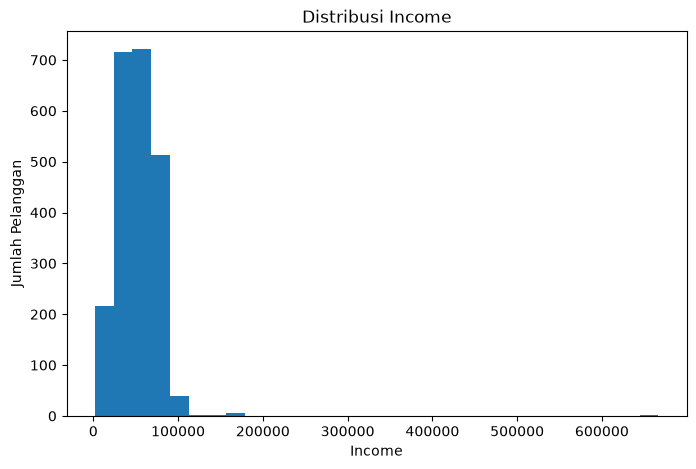

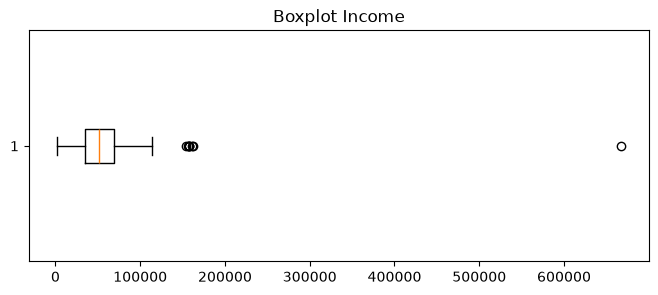

In [ ]:
# 3. Exploratory Data Analysis (EDA)
## 3.1. Visualisasi Distribusi Income
plt.figure(figsize=(8,5))
plt.hist(df['Income'].dropna(), bins=30)
plt.title('Distribusi Income')
plt.xlabel('Income')
plt.ylabel('Jumlah Pelanggan')
plt.show()

##3.2. Membuat Boxplot Income
plt.figure(figsize=(8,3))
plt.boxplot(
    df['Income'].dropna(), 
    orientation='horizontal'
)
plt.title('Boxplot Income')
plt.show()

In [ ]:
# 4. Data Cleaning
## 4.1. Menangani Missing Value
df['Income'] = df['Income'].fillna(df['Income'].median())
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [ ]:
## 4.2. Menghapus Kolom yang Tidak Diperlukan
df = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'])
df.shape
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='str')

In [ ]:
# 5. Feature Engineering
## 5.1. Mengubah Tipe Data Dt_Customer
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    format='%d-%m-%Y'
)
df.dtypes

Year_Birth                      int64
Education                         str
Marital_Status                    str
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[us]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Complain                        int64
Response                        int64
dtype: objec

In [ ]:
## 5.2. Membuat fitur Customer_Tenure
reference_date = df['Dt_Customer'].max()
df['Customer_Tenure'] = (
    reference_date - df['Dt_Customer']
).dt.days
df[['Dt_Customer','Customer_Tenure']].head()

,Dt_Customer,Customer_Tenure
0,2012-09-04,663
1,2014-03-08,113
2,2013-08-21,312
3,2014-02-10,139
4,2014-01-19,161


In [ ]:
## 5.3. Menghapus kolom Tanggal
df = df.drop(columns=['Dt_Customer'])
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Tenure
0,1957,Graduation,Single,58138.0,0,0,58,635,88,546,...,4,7,0,0,0,0,0,0,1,663
1,1954,Graduation,Single,46344.0,1,1,38,11,1,6,...,2,5,0,0,0,0,0,0,0,113
2,1965,Graduation,Together,71613.0,0,0,26,426,49,127,...,10,4,0,0,0,0,0,0,0,312
3,1984,Graduation,Together,26646.0,1,0,26,11,4,20,...,4,6,0,0,0,0,0,0,0,139
4,1981,PhD,Married,58293.0,1,0,94,173,43,118,...,6,5,0,0,0,0,0,0,0,161


In [ ]:
# 6. Penyederhanaan Kategori
## 6.1. Analisis Data Kategorikal
print("Education")
print(df['Education'].value_counts())
print("\n-----------------------\n")
print("Marital_Status")
print(df['Marital_Status'].value_counts())

Education
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

-----------------------

Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [ ]:
## 6.2. Membersihkan kategori Marital_Status
df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64

In [ ]:
# 7. One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=['Education', 'Marital_Status'],
    drop_first=False,
    dtype=int
)
df.shape
df.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,1957,58138.0,0,0,58,635,88,546,172,88,...,0,0,1,0,0,0,0,1,0,0
1,1954,46344.0,1,1,38,11,1,6,2,1,...,0,0,1,0,0,0,0,1,0,0
2,1965,71613.0,0,0,26,426,49,127,111,21,...,0,0,1,0,0,0,0,0,1,0
3,1984,26646.0,1,0,26,11,4,20,10,3,...,0,0,1,0,0,0,0,0,1,0
4,1981,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,0,1,0,1,0,0,0


In [11]:
## Memeriksa Variasi Setiap Fitur
df.nunique().sort_values()

Education_2n Cycle            2
Marital_Status_Single         2
Marital_Status_Divorced       2
Marital_Status_Married        2
Education_Master              2
Education_Graduation          2
Education_Basic               2
Education_PhD                 2
AcceptedCmp1                  2
Response                      2
Complain                      2
AcceptedCmp2                  2
AcceptedCmp4                  2
AcceptedCmp5                  2
AcceptedCmp3                  2
Marital_Status_Together       2
Marital_Status_Widow          2
Teenhome                      3
Kidhome                       3
NumCatalogPurchases          14
NumStorePurchases            14
NumWebPurchases              15
NumDealsPurchases            15
NumWebVisitsMonth            16
Year_Birth                   59
Recency                     100
MntFruits                   158
MntSweetProducts            177
MntFishProducts             182
MntGoldProds                213
MntMeatProducts             558
Customer

In [ ]:
# 8. Standarisasi Data
## 8.1 Data Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [ ]:
## 8.2. Membuat DataFrame Hasil Scaling
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)
scaled_df.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,-0.985345,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,...,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.339909,-0.792406,1.897258,-0.591099,-0.188676
1,-1.235733,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,...,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.339909,-0.792406,1.897258,-0.591099,-0.188676
2,-0.317643,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,...,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.339909,-0.792406,-0.527076,1.691765,-0.188676
3,1.268149,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,...,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.339909,-0.792406,-0.527076,1.691765,-0.188676
4,1.017761,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,...,-0.315684,-0.157171,-1.006270,-0.444816,1.899751,-0.339909,1.261980,-0.527076,-0.591099,-0.188676


In [ ]:
# 9. Menentukan Jumlah Cluster
## 9.1. Elbow Method
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

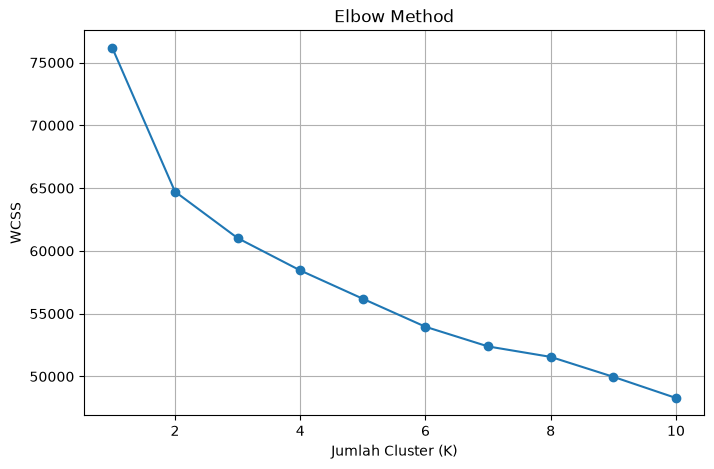

In [ ]:
## 9.2. Visualisasi Elbow Method
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
# 10. K-Means Clustering
## 10.1. Membuat model K-Means
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(scaled_df)
clusters

array([2, 1, 2, ..., 0, 0, 1], shape=(2240,), dtype=int32)

In [ ]:
# 10.2. Menambahkan Label Cluster
df['Cluster'] = clusters
df.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Cluster
0,1957,58138.0,0,0,58,635,88,546,172,88,...,0,1,0,0,0,0,1,0,0,2
1,1954,46344.0,1,1,38,11,1,6,2,1,...,0,1,0,0,0,0,1,0,0,1
2,1965,71613.0,0,0,26,426,49,127,111,21,...,0,1,0,0,0,0,0,1,0,2
3,1984,26646.0,1,0,26,11,4,20,10,3,...,0,1,0,0,0,0,0,1,0,1
4,1981,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,1,0,1,0,0,0,1


In [ ]:
## 10.3. Jumlah Data pada Setiap Cluster
df['Cluster'].value_counts().sort_index()

Cluster
0     601
1    1009
2     459
3     171
Name: count, dtype: int64

In [ ]:
# 11. Evaluasi Clustering
## Menghitung Silhouette Score
from sklearn.metrics import silhouette_score
score = silhouette_score(scaled_df, clusters)
print("Silhouette Score: ", round(score, 4))

Silhouette Score:  0.1078


In [ ]:
# 12. Visualisasi Hasil Clustering
## 12.1. Visualisasi PCA (Mereduksi Data ke 2 Dimensi)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

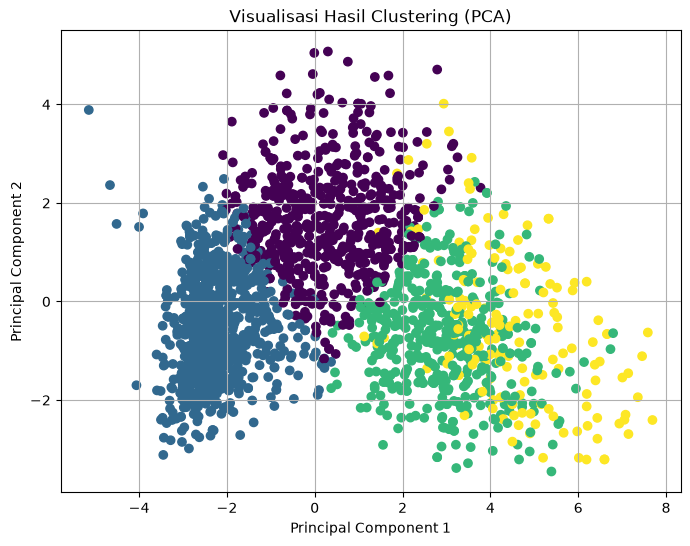

In [ ]:
## 12.2. Membuat Scatter Plot (Visualisasi Cluster)
plt.figure(figsize=(8,6))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters
)
plt.title("Visualisasi Hasil Clustering (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [ ]:
# 13. Analisis Karakteristik Setiap Cluster
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
cluster_summary

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1964.014975,56805.054077,0.249584,0.948419,47.935108,446.856905,19.444260,124.595674,25.544093,18.941764,...,0.048253,0.000000,0.457571,0.206323,0.287854,0.129784,0.396007,0.156406,0.277870,0.039933
1,1971.949455,34713.597126,0.804757,0.428147,49.566898,38.154609,5.010902,22.801784,7.301288,5.127849,...,0.112983,0.052527,0.488603,0.159564,0.186323,0.096135,0.390486,0.241824,0.248761,0.022795
2,1967.962963,73853.651416,0.052288,0.239651,49.372549,488.416122,70.862745,426.705882,104.928105,71.603486,...,0.104575,0.002179,0.588235,0.124183,0.180828,0.093682,0.348584,0.252723,0.257081,0.047930
3,1969.356725,81569.485380,0.052632,0.128655,49.830409,874.701754,56.426901,469.128655,77.052632,65.479532,...,0.070175,0.000000,0.520468,0.163743,0.245614,0.081871,0.421053,0.192982,0.257310,0.046784
